<a href="https://colab.research.google.com/github/imnishu07/TensorFlow_Lite_Projects/blob/SineWaveProject/Project3_Sine_Wave_DigiKey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%tensorflow_version 2.1

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
from tensorflow.keras import layers

In [5]:
#Print versions
!python --version
print('Numpy' + np.__version__)
print('TensorFlow' + tf.__version__)
print('Keras' + tf.keras.__version__)

Python 3.11.13
Numpy2.0.2
TensorFlow2.18.0
Keras3.8.0


In [6]:
#Settings
nsamples = 1000  #Number of samples to use as a dataset
val_ratio = 0.2  #Percentage of samples that should be held for validation set
test_ratio = 0.2 #Percentage of samples that should be held for test set
tflite_model_name = 'sine_model' #Will be given .tflite suffix
c_model_name = 'sine_model' #Will be given .h suffix

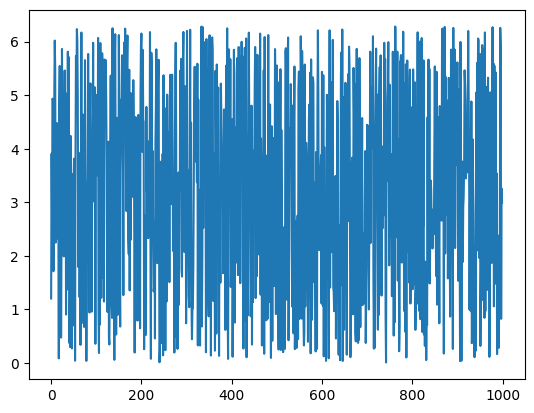

In [7]:
#Generate some random samples
np.random.seed(1234)
x_values = np.random.uniform(low=0, high=(2*math.pi), size=nsamples)
plt.plot(x_values)


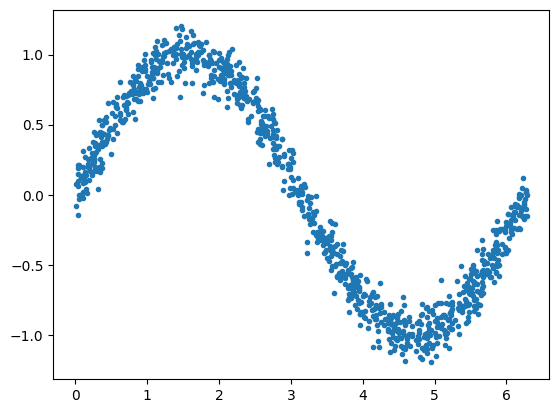

In [9]:
#Create a noisy sinewave with these values
y_values = np.sin(x_values) + (0.1*np.random.randn(x_values.shape[0]))
plt.plot(x_values, y_values, '.')


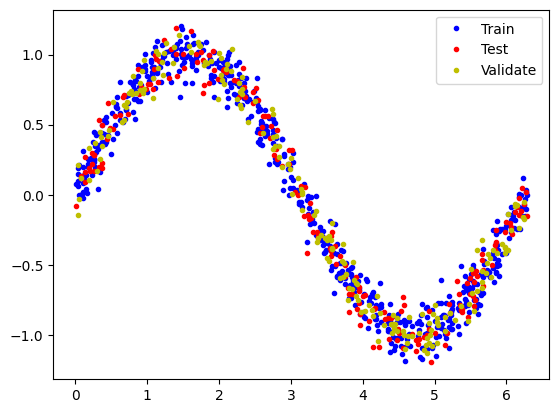

In [10]:
#Split the dataset into training, validation, and test sets
val_split = int(val_ratio * nsamples)
test_split = int(val_split + (test_ratio * nsamples))
x_val, x_test, x_train = np.split(x_values, [val_split, test_split])
y_val, y_test, y_train = np.split(y_values, [val_split, test_split])

#Check that our splits add up correctly
assert(x_train.size + x_val.size + x_test.size == nsamples)

#Plot the data in each partition in different colors:
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_val, y_val, 'y.', label="Validate")
plt.legend()
plt.show()

In [11]:
#Create a model
model = tf.keras.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(1,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#Add Optimizer, loss function and metrics to model and compile it
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

In [13]:
#Train model
history = model.fit(x_train, y_train, epochs=500, batch_size=100, validation_data=(x_val, y_val))

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.4378 - mae: 0.5789 - val_loss: 0.4039 - val_mae: 0.5525
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4210 - mae: 0.5666 - val_loss: 0.3802 - val_mae: 0.5283
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3744 - mae: 0.5204 - val_loss: 0.3688 - val_mae: 0.5210
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3839 - mae: 0.5352 - val_loss: 0.3566 - val_mae: 0.5106
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3582 - mae: 0.5134 - val_loss: 0.3515 - val_mae: 0.5106
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3480 - mae: 0.5062 - val_loss: 0.3407 - val_mae: 0.5023
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3415 - mae: 0.5031 - val_loss: 0.3306 - val_mae: 0.4946
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3347 - mae: 0.4927 - val_loss: 0.3224 - val_mae: 0.4894
Epoch 9/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3389 - mae: 

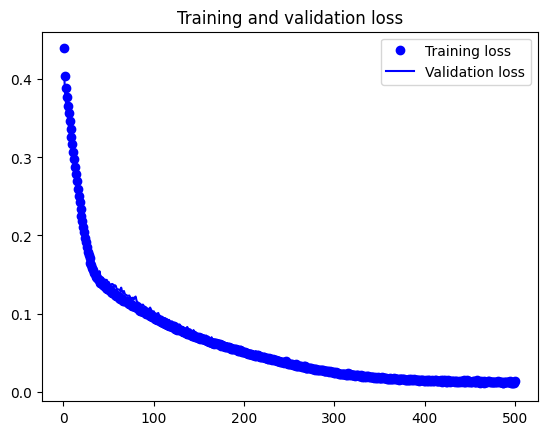

In [14]:
#Plot the training history
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


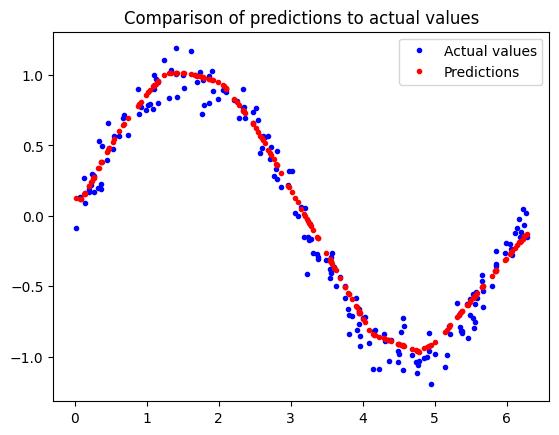

In [15]:
#Plot predictions against actual values
predictions = model.predict(x_test)
plt.clf

plt.title('Comparison of predictions to actual values')
plt.plot(x_test, y_test, 'b.', label='Actual values')
plt.plot(x_test, predictions, 'r.', label='Predictions')
plt.legend()
plt.show()

In [17]:
#Convert Keras model to a tflite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

open(tflite_model_name + '.tflite', 'wb').write(tflite_model)

Saved artifact at '/tmp/tmprtpso9tv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133152594467088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152594468240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152594467856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152594468624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152594464592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152594467664: TensorSpec(shape=(), dtype=tf.resource, name=None)


3168

In [18]:
#Function: Convert some hex value into an array for C programming
def hex_to_c_array(hex_data, var_name):

  c_str = ''

  #Create header guard
  c_str += 'ifndef' + var_name.upper() + '_H\n'
  c_str += '#define' + var_name.upper() + '_H\n\n'

  #Add array length at top of file
  c_str += '\nunsigned int ' + var_name + '_len = ' + str(len(hex_data)) + ';\n'

  #Declare C variable
  c_str += 'unsigned char' + var_name + '[] = {'
  hex_array = []
  for i, val in enumerate(hex_data) :

    #Convert each byte to a hex
    hex_str = format(val, '02X')

    #Add formatting so each line stays within 80 characters
    if(i + 1) < len(hex_data):
      hex_str += ','
    if(i + 1) % 12 == 0:
      hex_str += '\n'
    hex_array.append(hex_str)

  #Add closing brace
  c_str += '\n ' + format(' '.join(hex_array)) + '\n};\n\n'

  #Close out header guard
  c_str += '#endif //' + var_name.upper() + '_H'

  return c_str


In [20]:
#Write TFLite model to a C source (or header) file
with open(c_model_name + '.h', 'w') as file:
  file.write(hex_to_c_array(tflite_model, c_model_name))